# Voltage Dependence of EC50 in CaV Channels  
### Exploratory Computational Analysis

Introduction / Goal

- Analyze EC50 vs voltage data from CaV channel experiments  
- Explore whether the relationship is smooth or shows regime changes  

**Goal:** Understand how voltage affects EC50 behavior using simple modeling tools.

## 1. Raw Data and Initial Visualization

- Load EC50 vs voltage data
- Plot raw scatter data

**Purpose:**  
Initial visual inspection of the relationship between voltage and EC50.

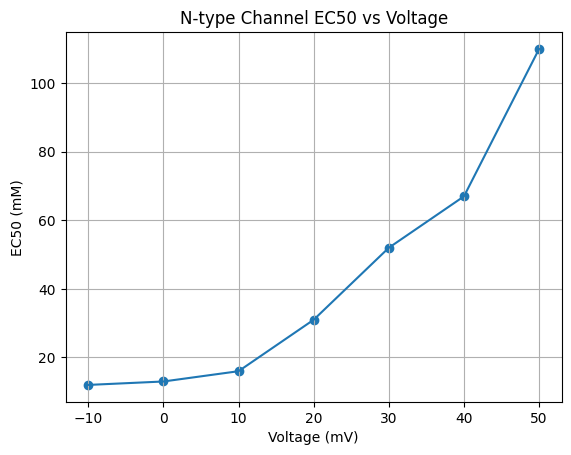

In [36]:
import numpy as np
import matplotlib.pyplot as plt
voltage = [-10, 0, 10, 20, 30, 40, 50]
ec50 = [12, 13, 16, 31, 52, 67, 110]

plt.scatter(voltage, ec50)
plt.plot(voltage, ec50)

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50 (mM)")
plt.title("N-type Channel EC50 vs Voltage")
plt.grid(True)

plt.show()

The channel's ion conduction efficiency decreases as voltage becomes more positive, so ion-channel interactions change with voltage.

Higher voltage makes the channel less efficient at conducting ions, so more ions are needed to get the same current.

## 2. Smooth vs Switch Behavior (Visual Intuition)

- Built conceptual comparison between:
  - smooth/permeation-like change
  - switch/gating-like change
      
**Purpose:**  
Focus was on visualizing different possible channel behaviors

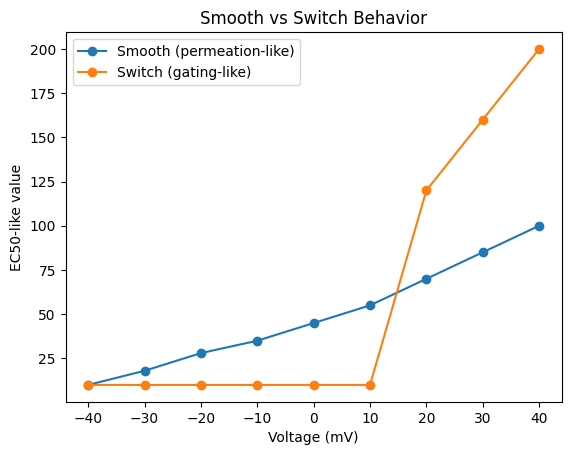

In [18]:
import matplotlib.pyplot as plt

# x-axis: voltage
voltage = [-40, -30, -20, -10, 0, 10, 20, 30, 40]

# smooth EC50-like behavior (gradual change)
smooth = [10, 18, 28, 35, 45, 55, 70, 85, 100]

# switch-like behavior (flat then sudden jump)
switch = [10, 10, 10, 10, 10, 10, 120, 160, 200]

plt.plot(voltage, smooth, marker='o', label='Smooth (permeation-like)')
plt.plot(voltage, switch, marker='o', label='Switch (gating-like)')

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50-like value")
plt.title("Smooth vs Switch Behavior")
plt.legend()
# plt.grid(True)

plt.show()


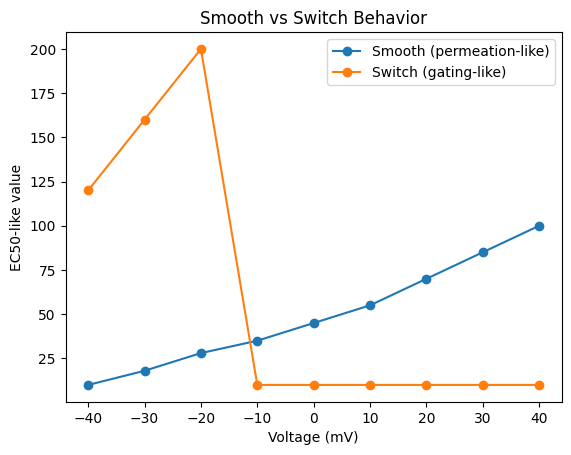

In [19]:
import matplotlib.pyplot as plt

# x-axis: voltage
voltage = [-40, -30, -20, -10, 0, 10, 20, 30, 40]

# smooth EC50-like behavior (gradual change)
smooth = [10, 18, 28, 35, 45, 55, 70, 85, 100]

# switch-like behavior (flat then sudden jump)
switch = [120, 160, 200, 10, 10, 10, 10, 10, 10,]

plt.plot(voltage, smooth, marker='o', label='Smooth (permeation-like)')
plt.plot(voltage, switch, marker='o', label='Switch (gating-like)')

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50-like value")
plt.title("Smooth vs Switch Behavior")
plt.legend()
# plt.grid(True)

plt.show()


## 3. Interactive Parameter Exploration (Sliders)

- Used sliders to adjust:
  - baseline
  - slope / sensitivity

**Purpose:**  
- Observed how parameter changes affect curve shape


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

V = np.linspace(-40, 60, 200)

def plot_ec50(baseline=10, slope=0.5, threshold=0):
    # EC50 increases mainly after a threshold (like your paper trend)
    EC50 = baseline + slope * np.maximum(V - threshold, 0)

    plt.plot(V, EC50)
    plt.xlabel("Voltage (mV)")
    plt.ylabel("EC50 (mM)")
    plt.title("EC50 vs Voltage (Toy Model)")
    plt.grid(True)
    plt.ylim(0, None)
    plt.show()

interact(plot_ec50,
         baseline=(5, 40, 1),
         slope=(0.0, 3.0, 0.1),
         threshold=(-20, 40, 1));

interactive(children=(IntSlider(value=10, description='baseline', max=40, min=5), FloatSlider(value=0.5, descr…

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

V = np.linspace(-40, 60, 200)

def plot_ec50(baseline=10, slope=0.3, midpoint=10, steepness=0.08):
    # smooth transition instead of a hard threshold
    EC50 = baseline + slope * (1 / (1 + np.exp(-steepness * (V - midpoint))))

    plt.plot(V, EC50)
    plt.xlabel("Voltage (mV)")
    plt.ylabel("EC50 (mM)")
    plt.title("Smooth EC50 vs Voltage (Toy Model)")
    plt.grid(True)
    plt.show()

interact(plot_ec50,
         baseline=(5, 40, 1),
         slope=(0.1, 5.0, 0.1),
         midpoint=(-20, 40, 1),
         steepness=(0.01, 0.2, 0.01));

interactive(children=(IntSlider(value=10, description='baseline', max=40, min=5), FloatSlider(value=0.3, descr…

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

V = np.linspace(-10, 60, 300)

def plot_ec50(baseline=12, curvature=0.02):
    # smooth curved growth (always curved, never a straight line)
    EC50 = baseline + curvature * (V + 10)**2

    plt.plot(V, EC50)
    plt.xlabel("Voltage (mV)")
    plt.ylabel("EC50")
    plt.title("Smooth EC50 vs Voltage (Curved)")
    plt.grid(True)
    plt.show()

interact(plot_ec50,
         baseline=(5, 30, 0.5),
         curvature=(0.0, 0.2, 0.01));

interactive(children=(FloatSlider(value=12.0, description='baseline', max=30.0, min=5.0, step=0.5), FloatSlide…

## 4. Smooth Functional Forms (Pre-Fitting Exploration)


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# voltage values from the paper table
V_data = np.array([-10, 0, 10, 20, 30, 40])

# N-type single channel EC50 (Ba2+)
EC50_data = np.array([12, 13, 16, 31, 52, 67])

In [47]:
def model(V, baseline, curvature):
    return baseline + curvature * (V + 10)**2

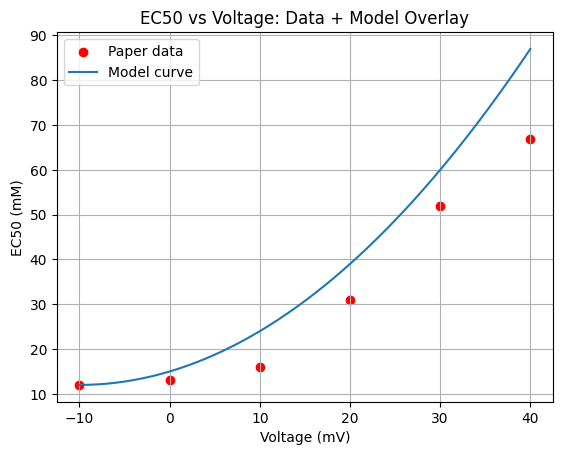

In [48]:
V_fit = np.linspace(-10, 40, 200)

baseline = 12
curvature = 0.03

EC50_fit = model(V_fit, baseline, curvature)

plt.figure()

# real data (points)
plt.scatter(V_data, EC50_data, color='red', label="Paper data")

# model (curve)
plt.plot(V_fit, EC50_fit, label="Model curve")

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50 (mM)")
plt.title("EC50 vs Voltage: Data + Model Overlay")
plt.legend()
plt.grid(True)

plt.show()

## 5. SciPy Curve Fitting

second-order regression, curve-fitting

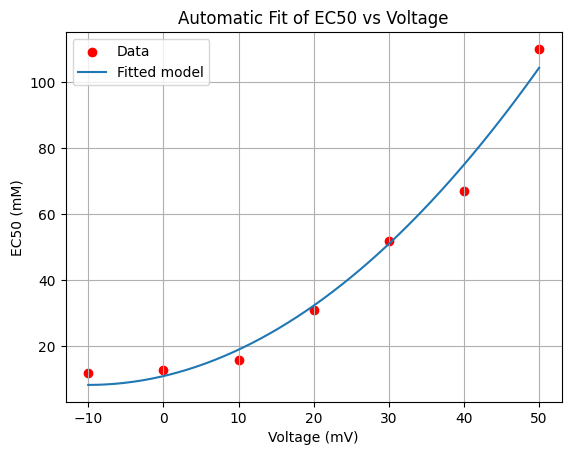

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data
V_data = np.array([-10, 0, 10, 20, 30, 40, 50])
EC50_data = np.array([12, 13, 16, 31, 52, 67, 110])

# model function
def model(V, intercept, quad_coeff):
    return intercept + quad_coeff * (V + 10)**2

# fit parameters automatically
params, _ = curve_fit(model, V_data, EC50_data)

baseline_fit, curvature_fit = params

# smooth curve for plotting
V_fit = np.linspace(-10, 50, 300)
EC50_fit = model(V_fit, baseline_fit, curvature_fit)

# plot
plt.scatter(V_data, EC50_data, color='red', label="Data")
plt.plot(V_fit, EC50_fit, label="Fitted model")

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50 (mM)")
plt.title("Automatic Fit of EC50 vs Voltage")
plt.legend()
plt.grid(True)
plt.show()

## 6. Piecewise Linear Modeling (Regime Split)

- Split data using Boolean masks:
  - low voltage region
  - high voltage region
- Fit separate linear models to each region
- Compared slopes between regimes

In [72]:
V_data = np.array([-10, 0, 10, 20, 30, 40, 50])
EC50_data = np.array([12, 13, 16, 31, 52, 67, 110])

In [73]:
# Split the two regions at 0mV
low_mask = V_data <= 0
high_mask = V_data > 0

In [74]:
V_low = V_data[low_mask]
EC50_low = EC50_data[low_mask]

V_high = V_data[high_mask]
EC50_high = EC50_data[high_mask]

In [75]:
# Check
print(V_low, EC50_low)
print(V_high, EC50_high)

[-10   0] [12 13]
[10 20 30 40 50] [ 16  31  52  67 110]


In [76]:
m_low, b_low = np.polyfit(V_low, EC50_low, 1)

In [77]:
m_high, b_high = np.polyfit(V_high, EC50_high, 1)

In [78]:
print("Low-voltage slope:", m_low)
print("High-voltage slope:", m_high)

Low-voltage slope: 0.10000000000000006
High-voltage slope: 2.24


dramatic increase in slope; there is a change in mechanism, not just a gradual trend

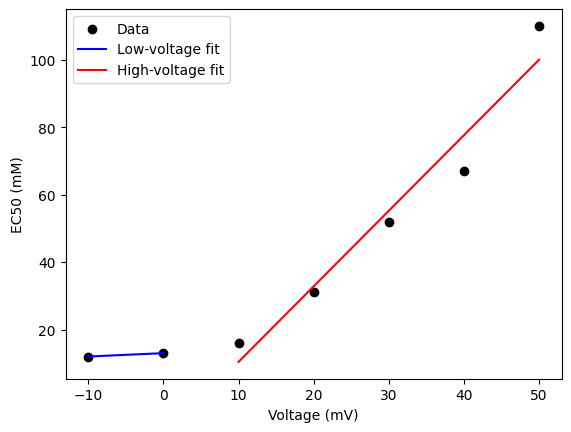

In [79]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

# Raw data
plt.scatter(V_data, EC50_data, label="Data", color="black")

# Low-voltage fit line
V_low_line = np.linspace(min(V_low), max(V_low), 100)
EC50_low_line = m_low * V_low_line + b_low
plt.plot(V_low_line, EC50_low_line, label="Low-voltage fit", color="blue")

# High-voltage fit line
V_high_line = np.linspace(min(V_high), max(V_high), 100)
EC50_high_line = m_high * V_high_line + b_high
plt.plot(V_high_line, EC50_high_line, label="High-voltage fit", color="red")

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50 (mM)")
plt.legend()
plt.show()

the system behaves differently in two voltage regions

## 7. Shared Breakpoint Model (0 mV)

- Built single piecewise function using `np.where`
- Fixed breakpoint at 0 mV
- Unified low- and high-voltage behavior in one model


In [80]:
def piecewise_model(V, m1, b1, m2, b2):
    return np.where(V <= 0,
                    m1 * V + b1,
                    m2 * V + b2)

In [81]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(piecewise_model, V_data, EC50_data)

m1, b1, m2, b2 = popt

In [82]:
V_fit = np.linspace(-10, 50, 300)
EC50_fit = piecewise_model(V_fit, m1, b1, m2, b2)

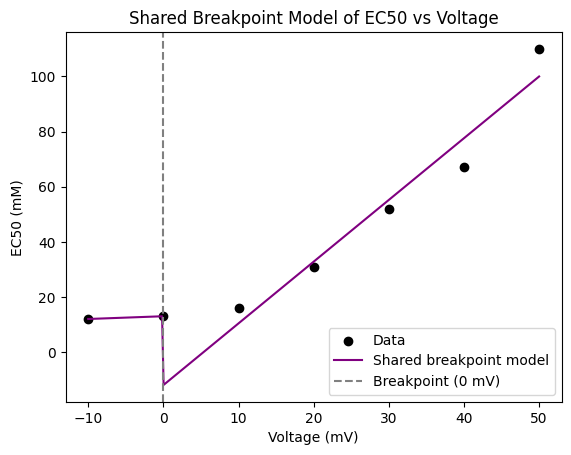

In [85]:
import matplotlib.pyplot as plt

plt.figure()

# data
plt.scatter(V_data, EC50_data, color="black", label="Data")

# model
plt.plot(V_fit, EC50_fit, color="purple", label="Shared breakpoint model")

plt.axvline(0, linestyle="--", color="gray", label="Breakpoint (0 mV)")

plt.xlabel("Voltage (mV)")
plt.ylabel("EC50 (mM)")
plt.title("Shared Breakpoint Model of EC50 vs Voltage")
plt.legend()
plt.show()